# Results over all events

Two studies, both regenerated by `run.py` and saved in `results/`:

- `results/study/` - the 10 catalog events inside the OpenMesh record, three link sets, every
  method, pooled per precipitation type (`python src/run.py study`).
- `results/all_events/` - all 52 events of the record on the selected links, ranked event by
  event (`python src/run.py all-events`).
- `results/validation/` - is the radar data right, and how close is each source to the official
  ASOS gauges (`python src/run.py validate`).

This notebook reads the saved tables; it does not recompute them.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nyc_rain_maps import plots

from IPython.display import Image, Markdown

R = Path("../results")

## Pooled against MRMS, by precipitation type

In [2]:
pooled = pd.read_csv(R / "study/pooled_scores.csv")
p = pooled[(pooled.link_set == "selected") & ~pooled.near]
order = {"rain": 0, "mix": 1, "snow": 2}
(p.assign(_t=p.ptype.map(order)).sort_values(["_t", "nrmse"])
  [["ptype", "method", "events", "coverage", "rel_bias", "nrmse", "corr", "csi"]].round(2))

,ptype,method,events,coverage,rel_bias,nrmse,corr,csi
46,rain,impl2_nearby,5,0.74,-0.27,0.57,0.86,0.86
44,rain,impl2_classical_dynamic,5,1.00,-0.09,0.60,0.81,0.91
40,rain,impl1_dynamic,5,1.00,-0.13,0.60,0.82,0.91
48,rain,impl2_pycomlink,5,1.00,-0.31,0.69,0.80,0.84
42,rain,impl2_classical_constant,5,1.00,-0.36,0.70,0.81,0.72
16,mix,impl2_nearby,3,0.98,0.25,1.77,0.37,0.57
10,mix,impl1_dynamic,3,1.00,0.92,2.79,0.47,0.62
12,mix,impl2_classical_constant,3,1.00,1.06,3.37,0.52,0.54
18,mix,impl2_pycomlink,3,1.00,1.49,3.63,0.51,0.68
14,mix,impl2_classical_dynamic,3,1.00,1.64,3.83,0.57,0.67


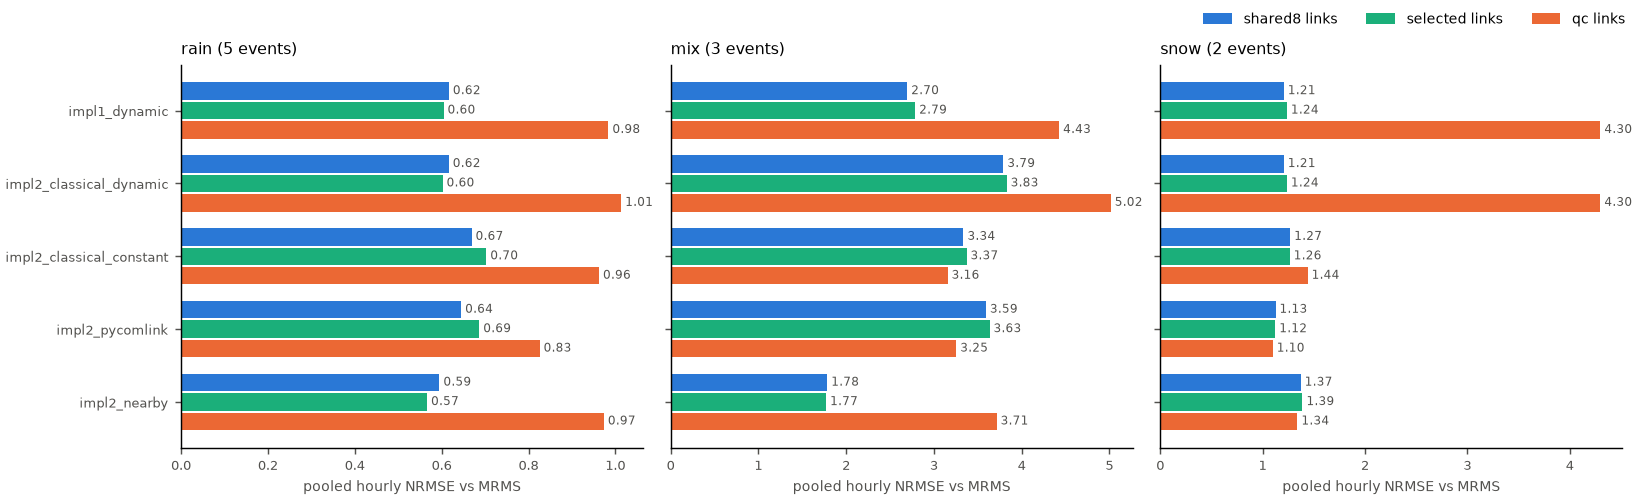

In [3]:
Image(R / "study/figures/nrmse_by_type.png")

## The sensors against each other (cells within 2 km of a link)

The PWS-MRMS disagreement is the floor any CML score should be read against.

In [4]:
sp = pd.read_csv(R / "study/sensor_pooled_scores.csv")
sp = sp[sp.reference == "MRMS"].assign(_t=lambda d: d.ptype.map(order)).sort_values(["_t", "nrmse"])
sp[["ptype", "estimate", "coverage", "rel_bias", "nrmse", "corr"]].round(2)

,ptype,estimate,coverage,rel_bias,nrmse,corr
21,rain,PWS,1.00,0.00,0.33,0.95
17,rain,CML impl2_nearby,0.74,-0.27,0.55,0.88
15,rain,CML impl2_classical_dynamic,1.00,-0.09,0.57,0.84
11,rain,CML impl1_dynamic,1.00,-0.13,0.58,0.83
19,rain,CML impl2_pycomlink,1.00,-0.32,0.70,0.79
13,rain,CML impl2_classical_constant,1.00,-0.37,0.72,0.80
10,mix,PWS,1.00,-0.52,1.08,0.50
6,mix,CML impl2_nearby,0.98,0.36,1.89,0.38
0,mix,CML impl1_dynamic,1.00,0.97,2.73,0.50
2,mix,CML impl2_classical_constant,1.00,1.12,3.42,0.54


## Event by event (rain, selected links)

In [5]:
wins = pd.read_csv(R / "all_events/win_counts_rain.csv", index_col=0)
wins.round(2)

,wins,median_rank,median_nrmse,median_bias,share_underestimating
impl1_dynamic,16,2.0,0.98,0.01,0.49
impl2_classical_dynamic,9,2.0,1.02,0.07,0.44
impl2_pycomlink,15,3.0,1.00,-0.49,0.96
impl2_classical_constant,1,4.0,1.17,-0.61,0.98
impl2_nearby,4,4.0,1.00,-0.60,1.00


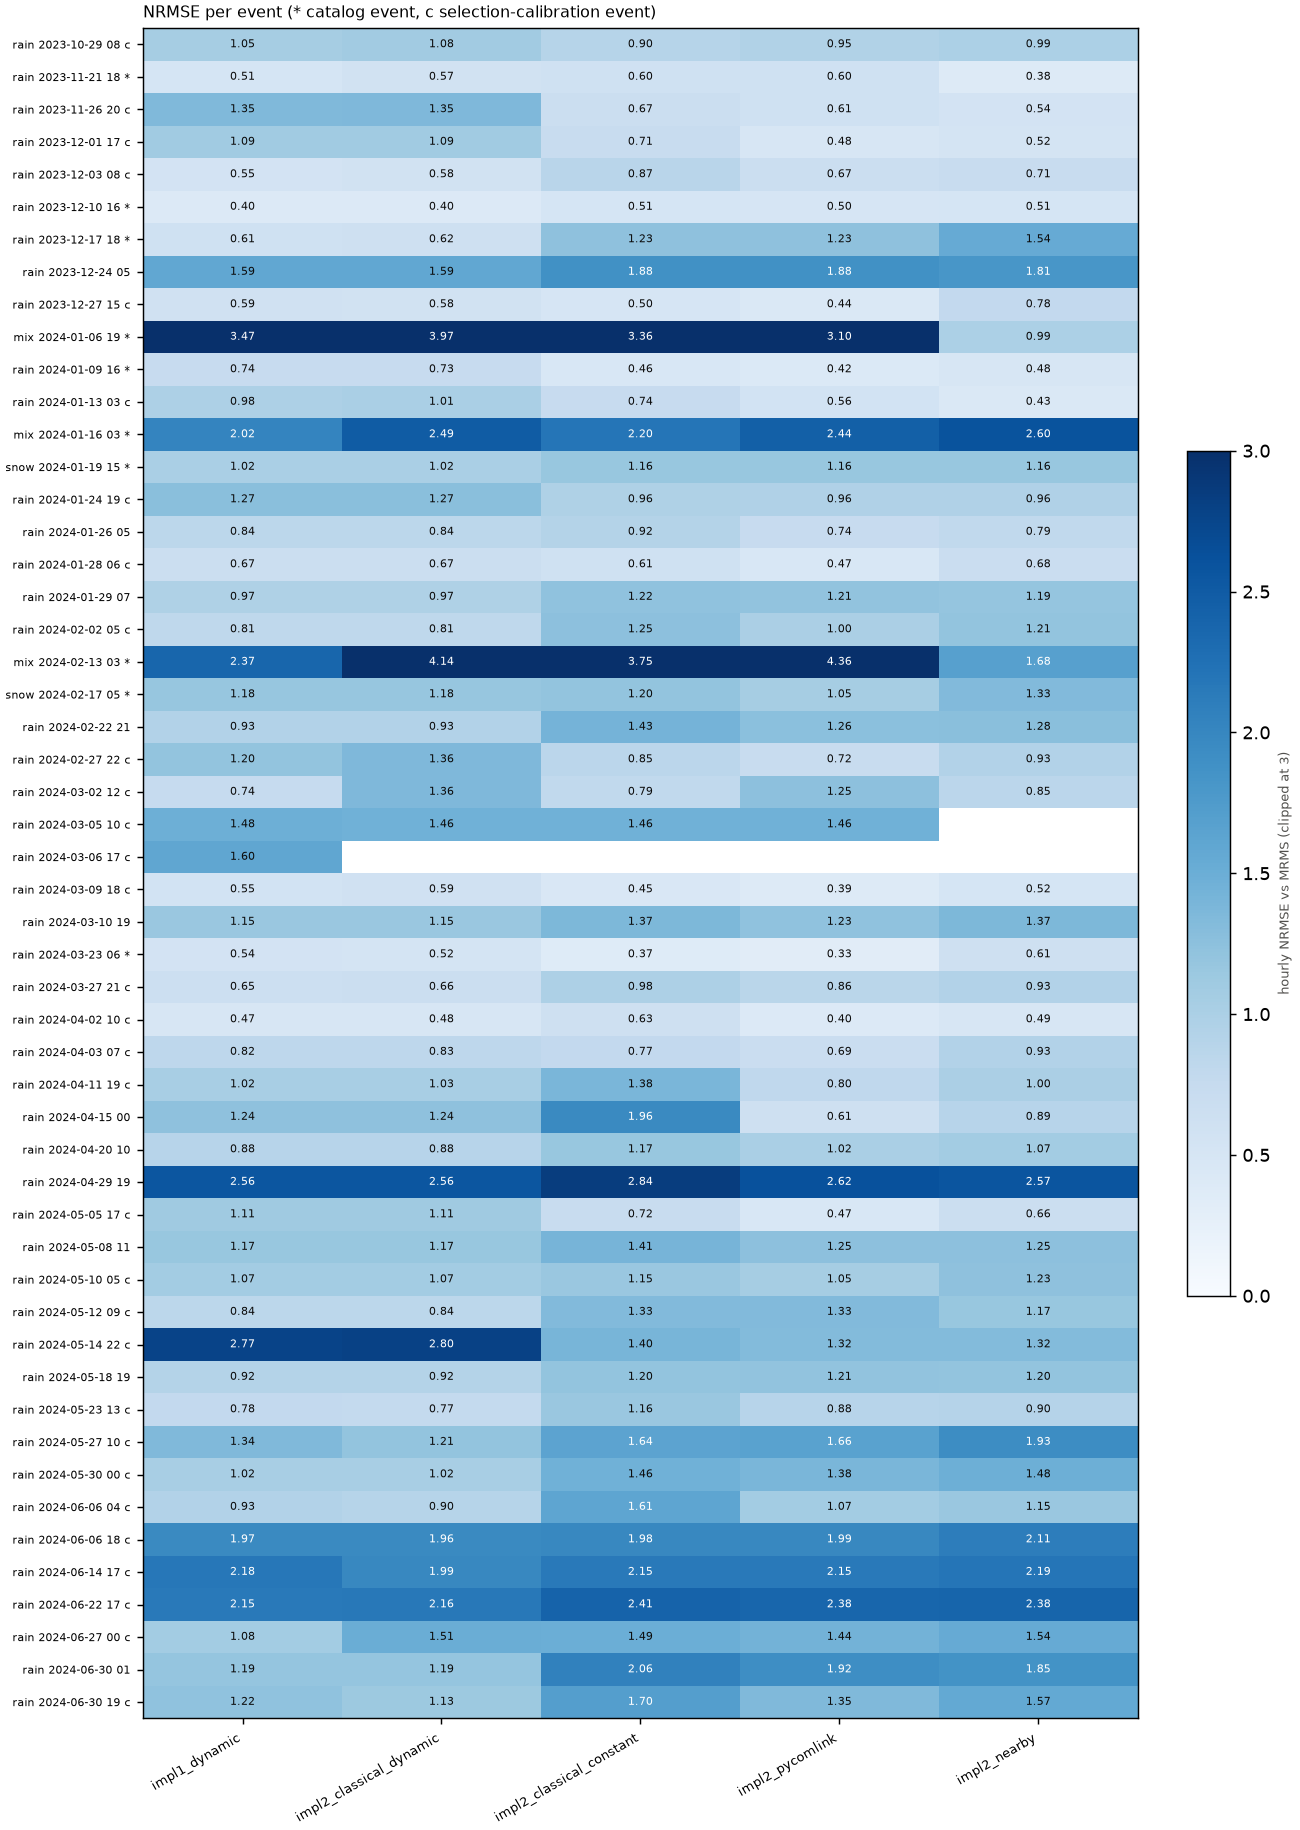

In [6]:
Image(R / "all_events/figures/nrmse_by_event.png")

## Each source against the official gauges

In [7]:
v = pd.read_csv(R / "validation/period_pooled.csv")
v[v.hours.isin(["rain", "snow", "mix"])].round(2)

,hours,source,coverage,n,mean_ref,mean_est,bias,rel_bias,mae,rmse,nrmse,corr,pod,far,csi,total_official_mm,total_source_mm
3,rain,MRMS Pass 2,1.00,1124,1.39,1.34,-0.05,-0.04,0.47,1.08,0.78,0.90,0.84,0.12,0.76,1560.96,1505.50
4,rain,PWS nearest (<3 km),0.44,1124,1.39,1.70,0.32,0.23,0.54,1.08,0.78,0.93,0.95,0.12,0.84,1560.96,1915.41
5,rain,PWS IDW,0.48,1124,1.39,1.53,0.14,0.10,0.43,0.88,0.63,0.94,0.96,0.14,0.83,1560.96,1721.98
6,snow,MRMS Pass 2,1.00,129,0.52,0.49,-0.04,-0.07,0.20,0.34,0.65,0.89,0.88,0.09,0.81,67.48,62.80
7,snow,PWS nearest (<3 km),0.51,129,0.52,0.12,-0.40,-0.77,0.48,0.85,1.62,0.23,0.19,0.22,0.18,67.48,15.75
8,snow,PWS IDW,0.51,129,0.52,0.13,-0.39,-0.75,0.45,0.81,1.55,0.32,0.32,0.12,0.31,67.48,16.77
9,mix,MRMS Pass 2,1.00,25,0.87,1.28,0.41,0.46,0.57,0.74,0.84,0.91,0.82,0.00,0.82,21.85,32.00
10,mix,PWS nearest (<3 km),0.41,25,0.87,0.94,0.07,0.08,0.70,1.18,1.35,0.95,0.59,0.00,0.59,21.85,23.62
11,mix,PWS IDW,0.41,25,0.87,0.68,-0.19,-0.22,0.48,0.65,0.74,0.94,0.59,0.00,0.59,21.85,17.13
